<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Weather Forecasting with LSTM Neural Networks

This notebook demonstrates how to build and train a Long Short-Term Memory (LSTM) neural network using TensorFlow/Keras to forecast weather data, specifically temperature. The process involves several key steps:

1.  **Data Loading and Initial Exploration**: Loading the dataset and understanding its structure.
2.  **Data Preprocessing**: Handling missing values, converting data types, and scaling features.
3.  **Sequence Creation**: Preparing the data into sequences suitable for LSTM input.
4.  **Model Definition**: Designing the LSTM model architecture.
5.  **Model Training**: Training the model on historical data.
6.  **Model Evaluation**: Assessing the model's performance on unseen data.
7.  **Future Forecasting**: Using the trained model to predict future weather conditions.
8.  **Model Saving**: Persisting the trained model for later use.

### Why LSTM for Time Series?
LSTMs are a type of recurrent neural network (RNN) particularly well-suited for processing sequences of data, like time series. They have internal memory mechanisms (gates) that allow them to learn long-term dependencies in the data, which is crucial for accurate forecasting based on past observations.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

print(tf.__version__)

2.20.0


In [24]:
# Import necessary libraries for data manipulation, visualization, and deep learning.
import os # For interacting with the operating system, e.g., file paths
import glob # For finding files matching a pattern
import numpy as np # For numerical operations, especially with arrays
import pandas as pd # For data manipulation and analysis using DataFrames
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations

# Import modules from scikit-learn for data preprocessing and evaluation metrics.
from sklearn.preprocessing import MinMaxScaler # For scaling features to a specific range
from sklearn.metrics import mean_squared_error, mean_absolute_error # For evaluating regression models

# Import modules from TensorFlow Keras for building and training the LSTM model.
from tensorflow.keras.models import Sequential # For creating a linear stack of layers
from tensorflow.keras.layers import LSTM, Dense, Dropout # LSTM for recurrent layers, Dense for fully connected layers, Dropout for regularization
from tensorflow.keras.callbacks import EarlyStopping # To stop training when a monitored quantity has stopped improving

import tensorflow as tf # The core TensorFlow library

# Print the TensorFlow version to confirm the environment setup.
print(tf.__version__)

2.20.0


### 1. Data Loading and Initial Exploration

This section focuses on loading the weather dataset and performing initial checks to understand its structure, identify data types, and get a general overview of the content.

In [2]:
dataset_path = "/content/drive/MyDrive/dataset/Weather_Dataset"

csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))

print(csv_files)

df = pd.read_csv(csv_files[0])

df.head()

['/content/drive/MyDrive/dataset/Weather_Dataset/weatherHistory.csv']


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [25]:
# Define the path where the dataset is located in Google Drive.
dataset_path = "/content/drive/MyDrive/dataset/Weather_Dataset"

# Use glob to find all files ending with '.csv' in the specified directory.
# This is useful if there are multiple CSV files and you need to select one or process all.
csv_files = glob.glob(os.path.join(dataset_path, "*.csv"))

# Print the list of found CSV files to confirm the data source.
print(csv_files)

# Read the first CSV file found into a pandas DataFrame.
# This assumes the relevant data is in the first CSV file.
df = pd.read_csv(csv_files[0])

# Display the first few rows of the DataFrame to get a quick overview of the data.
df.head()

['/content/drive/MyDrive/dataset/Weather_Dataset/weatherHistory.csv']


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


#### Data Loading from CSV

The code below defines the path to the dataset, finds all CSV files within that path, and then loads the first identified CSV file into a pandas DataFrame. This sets up the primary data structure for our analysis.

In [3]:
print(df.shape)

print(df.columns)

df.info()

df.describe()

(96453, 12)
Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [26]:
# Print the shape of the DataFrame (number of rows, number of columns).
# This tells us the total entries and features available.
print(df.shape)

# Print the names of all columns in the DataFrame.
# This helps in understanding the available features and their exact naming.
print(df.columns)

# Display a concise summary of the DataFrame, including data types and non-null values.
# This is crucial for identifying missing data and incorrect data types.
df.info()

# Generate descriptive statistics of the numerical columns in the DataFrame.
# This provides insights into the central tendency, dispersion, and shape of the distribution of each column.
df.describe()

(96453, 12)
Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


### 2. Data Preprocessing

This section deals with preparing the raw data for model training. It involves several steps to clean and transform the data into a suitable format, including handling missing values and ensuring correct data types.

#### Initial Data Inspection

Before proceeding, it's essential to understand the basic characteristics of the loaded dataset. This includes checking its dimensions, column names, data types, and summary statistics to identify any immediate issues or insights.

In [4]:
df = df.fillna(method='ffill')
df = df.fillna(method='bfill')

/tmp/ipykernel_603/3490755982.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_603/3490755982.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


In [27]:
# Fill any missing values using the 'forward-fill' method.
# This means that the last valid observation is propagated forward to next missing values.
df = df.fillna(method='ffill')

# After forward-filling, there might still be missing values at the beginning of the dataset.
# We then use 'backward-fill' to fill any remaining NaNs by propagating the next valid observation backward.
df = df.fillna(method='bfill')

/tmp/ipykernel_603/926384240.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_603/926384240.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


#### Handling Missing Values

Missing values can negatively impact model performance. Here, we use forward-fill (`ffill`) and backward-fill (`bfill`) methods to impute missing data. `ffill` propagates the last valid observation forward, and `bfill` propagates the next valid observation backward. This ensures that all gaps are filled, assuming a temporal dependency in the data.

In [5]:
date_col = None

for col in df.columns:
    if "date" in col.lower():
        date_col = col
        break

print("Date Column :", date_col)

df[date_col] = pd.to_datetime(df[date_col])

df = df.sort_values(date_col)

Date Column : Formatted Date


/tmp/ipykernel_603/2909283578.py:10: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[date_col] = pd.to_datetime(df[date_col])


In [28]:
# Initialize a variable to store the name of the date column.
date_col = None

# Iterate through column names to find one containing 'date' (case-insensitive).
# This makes the code robust to different naming conventions for the date column.
for col in df.columns:
    if "date" in col.lower():
        date_col = col
        break

# Print the identified date column to verify.
print("Date Column :", date_col)

# Convert the identified date column to datetime objects.
# This allows for time-based indexing and operations.
df[date_col] = pd.to_datetime(df[date_col])

# Sort the DataFrame by the date column to ensure chronological order.
# This is critical for time series forecasting.
df = df.sort_values(date_col)

Date Column : Formatted Date


/tmp/ipykernel_603/133181182.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[date_col] = pd.to_datetime(df[date_col])


#### Date Column Processing

For time series analysis, the date column is crucial. This step identifies the date column, converts it to a datetime object, and sorts the DataFrame by date to ensure proper temporal order, which is essential for LSTM models.

In [6]:
numeric_df = df.select_dtypes(include=['float64','int64'])

numeric_df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
2880,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66
2881,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15
2882,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87
2883,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56
2884,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98


In [29]:
# Selects only the columns with 'float64' or 'int64' data types.
# This creates a new DataFrame containing only numerical features, which are suitable for scaling and model input.
numeric_df = df.select_dtypes(include=['float64','int64'])

# Display the first few rows of the new numerical DataFrame to inspect its contents.
numeric_df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
2880,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66
2881,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15
2882,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87
2883,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56
2884,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98


#### Selecting Numerical Features

LSTM models typically work with numerical input. This step isolates only the numerical columns from the DataFrame, as these will be used for scaling and sequence generation.

In [7]:
target_column = numeric_df.columns[0]

print("Target :", target_column)

Target : Temperature (C)


In [30]:
# Identify the target column for prediction. Here, we assume it's the first numerical column.
target_column = numeric_df.columns[0]

# Print the name of the target column to confirm.
print("Target :", target_column)

Target : Temperature (C)


#### Identifying the Target Column

Here, we explicitly define which numerical column we intend to predict. In this case, it's the first numerical column in our `numeric_df`, which is 'Temperature (C)'.

In [8]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(numeric_df)

scaled_data.shape

(96453, 8)

In [31]:
# Initialize MinMaxScaler to scale the numerical features.
# Scaling helps neural networks converge faster and perform better.
scaler = MinMaxScaler()

# Fit the scaler to the numerical DataFrame and transform the data.
# The data will be scaled to a range between 0 and 1.
scaled_data = scaler.fit_transform(numeric_df)

# Print the shape of the scaled data to confirm its dimensions.
scaled_data.shape

(96453, 8)

#### Scaling Numerical Data

Neural networks, especially LSTMs, perform better when input data is scaled. `MinMaxScaler` scales all features to a range between 0 and 1. This normalization helps the model converge faster and improves performance.

In [9]:
sequence_length = 30

X = []
y = []

target_index = numeric_df.columns.get_loc(target_column)

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i])

    y.append(scaled_data[i,target_index])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(96423, 30, 8)
(96423,)


In [32]:
# Define the length of each input sequence (number of previous time steps to consider).
# A longer sequence allows the model to learn longer-term dependencies.
sequence_length = 30

# Initialize empty lists to store input sequences (X) and corresponding target values (y).
X = []
y = []

# Get the index of the target column in the numeric_df. This is needed to extract the correct 'y' values.
target_index = numeric_df.columns.get_loc(target_column)

# Loop through the scaled data to create sequences.
# For each iteration, a sequence of 'sequence_length' data points is created for X,
# and the next data point of the target column is taken as y.
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i]) # X contains 'sequence_length' previous time steps
    y.append(scaled_data[i,target_index]) # y contains the target value at the current time step

# Convert the lists to NumPy arrays, which are required for Keras input.
X = np.array(X)
y = np.array(y)

# Print the shapes of X and y to verify the dimensions.
# X should be (number_of_samples, sequence_length, number_of_features)
# y should be (number_of_samples,)
print(X.shape)
print(y.shape)

(96423, 30, 8)
(96423,)


### 3. Sequence Creation for LSTM

LSTMs require input data to be in a sequential format. This step transforms the scaled data into sequences, where each sequence consists of `sequence_length` previous time steps, and the target `y` is the value to be predicted at the next time step. This is a crucial step for preparing time series data for recurrent neural networks.

In [10]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [33]:
# Define the split point for training and testing data (80% for training).
split = int(len(X)*0.8)

# Split the input sequences (X) into training and testing sets.
X_train = X[:split]
X_test = X[split:]

# Split the target values (y) into training and testing sets, corresponding to X.
y_train = y[:split]
y_test = y[split:]

#### Splitting Data into Training and Testing Sets

To evaluate the model's performance on unseen data, the sequences are split into training and testing sets. A common practice is to use a significant portion for training (e.g., 80%) and the rest for testing. This ensures that the model is trained on historical data and tested on future data it hasn't seen before.

In [14]:
model = Sequential()

model.add(LSTM(
    128,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,665 (475.25 KB)

 Trainable params: 121,665 (475.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Initialize a sequential Keras model.
model = Sequential()

# Add the first LSTM layer.
# 128 units: number of LSTM cells (memory units).
# return_sequences=True: ensures that the output of this LSTM layer is also a sequence,
# which is necessary when stacking multiple LSTM layers.
# input_shape: defines the shape of the input data (sequence_length, number_of_features).
model.add(LSTM(
    128,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

# Add a Dropout layer to prevent overfitting.
# 0.2 means 20% of the neurons will be randomly dropped during training.
model.add(Dropout(0.2))

# Add a second LSTM layer.
# 64 units: number of LSTM cells.
# return_sequences=False (default): the output of this layer will be a single vector,
# suitable for feeding into a Dense layer.
model.add(LSTM(64))

# Add another Dropout layer for further regularization.
model.add(Dropout(0.2))

# Add a Dense (fully connected) layer with 32 units and ReLU activation.
# ReLU (Rectified Linear Unit) is a common activation function.
model.add(Dense(32, activation='relu'))

# Add the output Dense layer with 1 unit (for predicting a single value).
# No activation function is specified, making it a linear output, suitable for regression.
model.add(Dense(1))

# Compile the model.
# optimizer='adam': an efficient optimization algorithm.
# loss='mse': Mean Squared Error, a common loss function for regression tasks.
# metrics=['mae']: Mean Absolute Error, an additional metric to monitor during training.
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Print a summary of the model architecture, including the number of parameters.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,665 (475.25 KB)

 Trainable params: 121,665 (475.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4. LSTM Model Definition

This section defines the architecture of the LSTM neural network. It consists of multiple LSTM layers, Dropout layers for regularization, and Dense layers for output. The model is compiled with an optimizer, loss function, and metrics.

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 0.0011 - mae: 0.0263 - val_loss: 0.0020 - val_mae: 0.0354
Epoch 2/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 7.1695e-04 - mae: 0.0206 - val_loss: 0.0017 - val_mae: 0.0324
Epoch 3/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - loss: 6.0405e-04 - mae: 0.0187 - val_loss: 0.0014 - val_mae: 0.0292
Epoch 4/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 5.5098e-04 - mae: 0.0178 - val_loss: 0.0020 - val_mae: 0.0369
Epoch 5/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - loss: 4.9993e-04 - mae: 0.0169 - val_loss: 0.0018 - val_mae: 0.0329
Epoch 6/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 4.7410e-04 - mae: 0.0163 - val_loss: 0.0017 - val_mae: 0.0334
Epoch 7/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - loss: 4.4546e-04 - mae: 0.0158 - val_loss: 0.0017 - val_mae: 0.0326
Epoch 8/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 74s 38ms/step - loss: 4.3276e-04 - mae: 0.0156 - val_loss: 0.0029 - val_mae: 0.0

In [ ]:
# Define an EarlyStopping callback.
# monitor='val_loss': monitors the validation loss.
# patience=10: training will stop if validation loss doesn't improve for 10 consecutive epochs.
# restore_best_weights=True: restores the model weights from the epoch with the best validation loss.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the LSTM model.
# X_train, y_train: training data and labels.
# epochs=20: maximum number of training iterations.
# batch_size=32: number of samples per gradient update.
# validation_split=0.2: 20% of the training data will be used for validation.
# callbacks=[early_stop]: apply the EarlyStopping mechanism.
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 79s 40ms/step - loss: 0.0030 - mae: 0.0383 - val_loss: 7.0681e-04 - val_mae: 0.0209
Epoch 2/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 9.0570e-04 - mae: 0.0232 - val_loss: 4.6931e-04 - val_mae: 0.0170
Epoch 3/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 6.8969e-04 - mae: 0.0201 - val_loss: 3.6566e-04 - val_mae: 0.0148
Epoch 4/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 75s 39ms/step - loss: 6.1041e-04 - mae: 0.0188 - val_loss: 3.8330e-04 - val_mae: 0.0147
Epoch 5/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - loss: 5.6375e-04 - mae: 0.0180 - val_loss: 6.5797e-04 - val_mae: 0.0204
Epoch 6/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - loss: 5.3058e-04 - mae: 0.0174 - val_loss: 6.6086e-04 - val_mae: 0.0197
Epoch 7/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - loss: 4.8937e-04 - mae: 0.0167 - val_loss: 6.4774e-04 - val_mae: 0.0190
Epoch 8/20
1929/1929 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - loss: 4.6471e-04 - mae: 0.0162 - val

### 5. Model Training

The model is trained using the `fit` method on the training data. `EarlyStopping` is used as a callback to prevent overfitting and save the best model weights. The training history (loss and metrics) is recorded for later analysis.

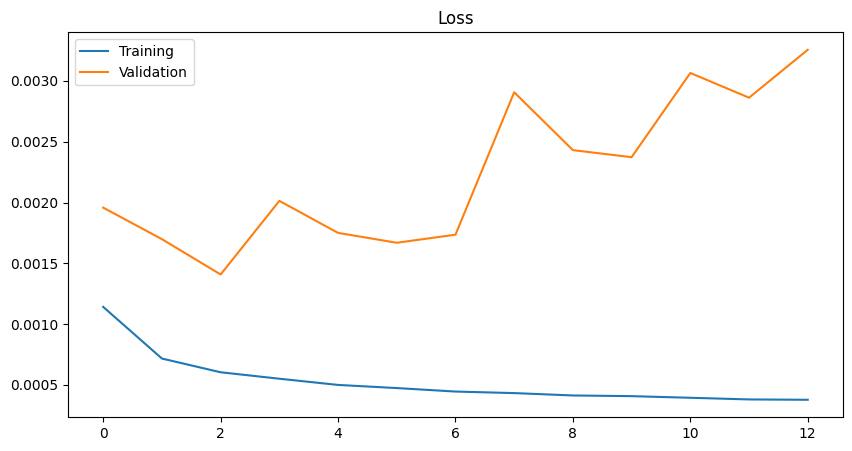

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label="Training")

plt.plot(history.history['val_loss'],label="Validation")

plt.legend()

plt.title("Loss")

plt.show()

In [ ]:
# Create a figure for the plot with a specified size.
plt.figure(figsize=(10,5))

# Plot the training loss from the history object.
plt.plot(history.history['loss'],label="Training")

# Plot the validation loss from the history object.
plt.plot(history.history['val_loss'],label="Validation")

# Display the legend to differentiate between training and validation loss.
plt.legend()

# Set the title of the plot.
plt.title("Loss")

# Display the plot.
plt.show()

#### Visualizing Training History

Plotting the training and validation loss over epochs helps in understanding the learning process and identifying potential overfitting or underfitting. A converging loss curve indicates a well-trained model.

In [16]:
predictions = model.predict(X_test)

603/603 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step


In [ ]:
# Generate predictions on the unseen test data (X_test).
predictions = model.predict(X_test)

### 6. Model Evaluation

After training, the model's performance is evaluated on the test set. This involves making predictions, inverse transforming the scaled predictions and actual values, and then calculating metrics like Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).

In [17]:
temp = np.zeros((len(predictions), scaled_data.shape[1]))
temp[:,target_index] = predictions[:,0]

pred_actual = scaler.inverse_transform(temp)[:,target_index]

temp = np.zeros((len(y_test), scaled_data.shape[1]))
temp[:,target_index] = y_test

y_actual = scaler.inverse_transform(temp)[:,target_index]

In [ ]:
# Create a temporary array of zeros with the same number of rows as predictions
# and the same number of columns as the original scaled data.
temp = np.zeros((len(predictions), scaled_data.shape[1]))
# Place the predictions into the target column's position in the temporary array.
temp[:,target_index] = predictions[:,0]

# Inverse transform the predictions back to their original scale.
# We only need the target column's values after inverse transformation.
pred_actual = scaler.inverse_transform(temp)[:,target_index]

# Repeat the process for the actual test values (y_test).
# Create a temporary array for y_test.
temp = np.zeros((len(y_test), scaled_data.shape[1]))
# Place y_test values into the target column's position.
temp[:,target_index] = y_test

# Inverse transform y_test values back to their original scale.
y_actual = scaler.inverse_transform(temp)[:,target_index]

#### Inverse Scaling Predictions

Since the model was trained on scaled data, the predictions are also scaled. This step inverse transforms both the predictions and the actual test values back to their original scale, making them interpretable and comparable.

In [18]:
rmse = np.sqrt(mean_squared_error(y_actual,pred_actual))

mae = mean_absolute_error(y_actual,pred_actual)

print("RMSE :",rmse)
print("MAE :",mae)

RMSE : 34.55194189238847
MAE : 33.14766677618354


In [ ]:
# Calculate Root Mean Squared Error (RMSE).
# RMSE is a quadratic scoring rule that measures the average magnitude of the errors.
rmse = np.sqrt(mean_squared_error(y_actual,pred_actual))

# Calculate Mean Absolute Error (MAE).
# MAE is a measure of errors between paired observations expressing the same phenomenon.
mae = mean_absolute_error(y_actual,pred_actual)

# Print the calculated RMSE and MAE values.
print("RMSE :",rmse)
print("MAE :",mae)

#### Calculating Evaluation Metrics

RMSE and MAE are commonly used metrics for regression tasks. RMSE gives a higher weight to larger errors, while MAE provides a more robust measure of average error. These metrics help quantify the difference between the model's predictions and the actual values.

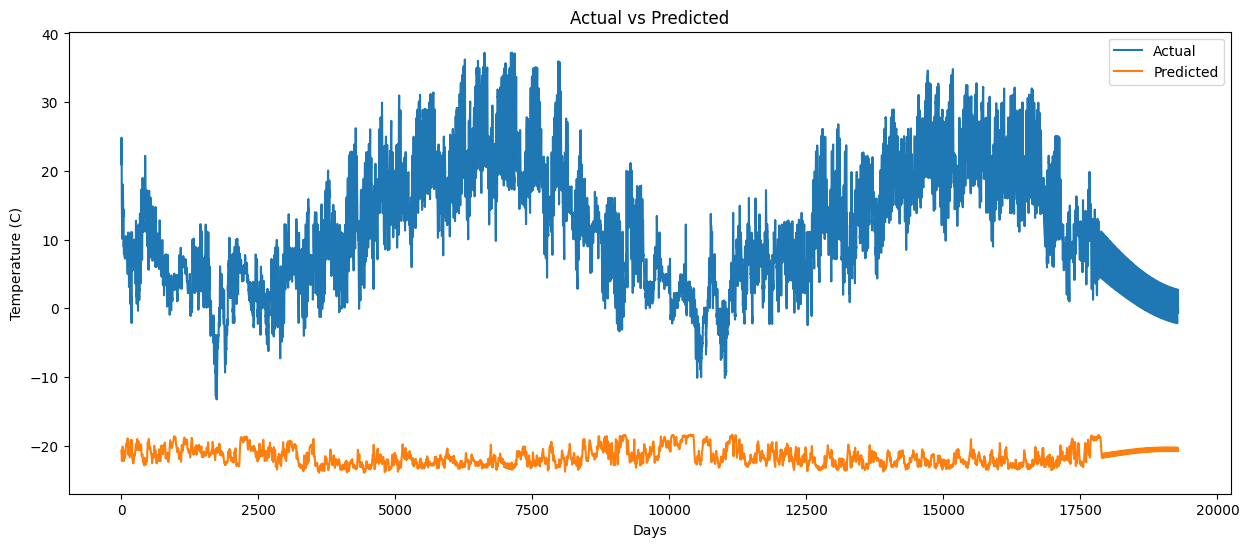

In [19]:
plt.figure(figsize=(15,6))

plt.plot(y_actual,label="Actual")

plt.plot(pred_actual,label="Predicted")

plt.xlabel("Days")

plt.ylabel(target_column)

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

In [ ]:
# Create a figure for the plot with a specified size.
plt.figure(figsize=(15,6))

# Plot the actual values from the test set.
plt.plot(y_actual,label="Actual")

# Plot the predicted values from the model.
plt.plot(pred_actual,label="Predicted")

# Label the x-axis.
plt.xlabel("Days")

# Label the y-axis with the target column name.
plt.ylabel(target_column)

# Set the title of the plot.
plt.title("Actual vs Predicted")

# Display the legend.
plt.legend()

# Display the plot.
plt.show()

#### Visualizing Actual vs. Predicted Values

A plot comparing the actual values against the predicted values helps visually assess the model's accuracy and identify any systematic biases or patterns in the errors.

In [20]:
future_days = 7

last_sequence = scaled_data[-sequence_length:]

future_predictions = []

current = last_sequence.copy()

for i in range(future_days):

    pred = model.predict(
        current.reshape(
            1,
            sequence_length,
            scaled_data.shape[1]
        ),
        verbose=0
    )

    future_predictions.append(pred[0,0])

    next_row = current[-1].copy()

    next_row[target_index] = pred

    current = np.vstack([current[1:],next_row])

/tmp/ipykernel_603/4269022781.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row[target_index] = pred


In [ ]:
# Define the number of future days to forecast.
future_days = 7

# Get the last sequence of data from the scaled dataset.
# This will be used as the initial input for forecasting.
last_sequence = scaled_data[-sequence_length:]

# Initialize an empty list to store future predictions.
future_predictions = []

# Create a copy of the last sequence to avoid modifying the original data.
current = last_sequence.copy()

# Loop to predict 'future_days' into the future.
for i in range(future_days):

    # Make a prediction using the current sequence.
    # The sequence needs to be reshaped to (1, sequence_length, number_of_features)
    # for the model.predict method.
    pred = model.predict(
        current.reshape(
            1,
            sequence_length,
            scaled_data.shape[1]
        ),
        verbose=0 # Suppress verbose output during prediction
    )

    # Append the predicted value (first element of the prediction array) to the list.
    future_predictions.append(pred[0,0])

    # Prepare the next input sequence.
    # Take the last row of the current sequence.
    next_row = current[-1].copy()

    # Update the target column in the 'next_row' with the new prediction.
    next_row[target_index] = pred

    # Append the 'next_row' to the current sequence and remove the oldest row.
    # This creates a sliding window effect for sequential forecasting.
    current = np.vstack([current[1:],next_row])

### 7. Future Forecasting

This section demonstrates how to use the trained LSTM model to forecast future weather conditions for a specified number of days. It involves an iterative process where the model predicts one step ahead, and that prediction is then incorporated into the input sequence for the next prediction.

In [21]:
future_scaled = np.zeros((future_days,scaled_data.shape[1]))

future_scaled[:,target_index] = future_predictions

future_temperature = scaler.inverse_transform(future_scaled)[:,target_index]

future_temperature

array([-20.77707374, -20.78468521, -20.77832538, -20.72434071,
       -20.64064393, -20.56284306, -20.49350655])

In [ ]:
# Create a zero array to hold the future scaled data, maintaining the original number of features.
future_scaled = np.zeros((future_days,scaled_data.shape[1]))

# Insert the predicted future values into the target column of the 'future_scaled' array.
future_scaled[:,target_index] = future_predictions

# Inverse transform the 'future_scaled' array to get the actual forecasted temperature values.
future_temperature = scaler.inverse_transform(future_scaled)[:,target_index]

# Display the forecasted future temperature values.
future_temperature

#### Inverse Scaling Future Predictions

Similar to the evaluation step, the future predictions are scaled, so they need to be inverse transformed back to their original scale for meaningful interpretation.

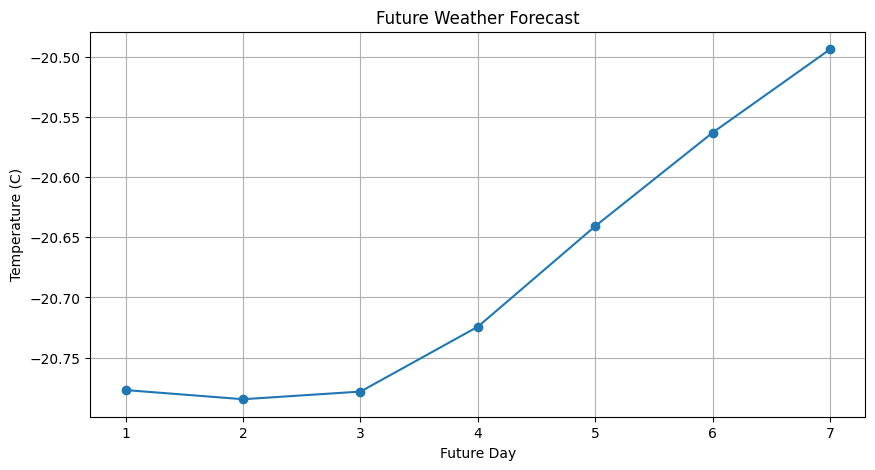

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1,future_days+1),
    future_temperature,
    marker='o'
)

plt.xlabel("Future Day")

plt.ylabel(target_column)

plt.title("Future Weather Forecast")

plt.grid(True)

plt.show()

In [ ]:
# Create a figure for the plot with a specified size.
plt.figure(figsize=(10,5))

# Plot the forecasted future temperatures.
# range(1, future_days+1) provides day labels (Day 1, Day 2, etc.).
# marker='o' adds markers to each data point for better visibility.
plt.plot(
    range(1,future_days+1),
    future_temperature,
    marker='o'
)

# Label the x-axis.
plt.xlabel("Future Day")

# Label the y-axis with the target column name.
plt.ylabel(target_column)

# Set the title of the plot.
plt.title("Future Weather Forecast")

# Add a grid to the plot for easier reading.
plt.grid(True)

# Display the plot.
plt.show()

#### Visualizing Future Forecast

A plot of the future forecasted temperatures provides a clear visual representation of the model's predictions for the upcoming days.

In [23]:
model.save("Weather_LSTM_Model.h5")

In [ ]:
# Save the trained Keras model to an HDF5 file.
# This allows you to load the model later without retraining.
model.save("Weather_LSTM_Model.h5")

## Conclusion

This notebook provides a comprehensive guide to building and utilizing an LSTM model for weather forecasting. We covered data loading, preprocessing, sequence generation, model architecture design, training with early stopping, evaluation using RMSE and MAE, and ultimately, predicting future weather conditions. The process highlights the power of LSTMs in handling sequential data for predictive tasks.

### 8. Model Saving

Finally, the trained LSTM model is saved to a file (`.h5` format). This allows the model to be loaded later without needing to retrain it, which is useful for deployment or further analysis.